In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [47]:
mert_idok_1 = np.array([[3.77, 3.61, 3.59],
[4.16, 3.75, 3.88],
[4.56, 4.60, 4.59],
[5.32, 5.31, 5.31],
[5.84, 5.79, 5.92],
[6.39, 6.47, 6.25]])

mert_idok_2 = np.array([[4.82, 4.80, 4.78],
[6.72, 6.74, 6.87],
[8.17, 8.32, 8.24],
[9.38, 9.43, 9.49],
[10.49 ,10.55 ,10.45],
[11.38 ,11.31 ,11.30]])

tavolsagok_1 = np.array([42.75,
41.05,
39.30,
37.55,
35.85,
34.10]) / 100

tavolsagok_2 = np.array([39.85,
34.45,
28.95,
23.70,
18.30,
12.95]) / 100

tomegek = np.array([50,
100,
150,
200,
250,
300]) / 1000

x0_1 = 44.5 / 100
x0_2 = 45.4 / 100

g = 9.81

In [48]:
atlag_idok_1 = np.array([np.average(i) for i in mert_idok_1])
atlag_idok_2 = np.array([np.average(i) for i in mert_idok_2])
periodusidok_1 = atlag_idok_1 / 10
periodusidok_2 = atlag_idok_2 / 10
megnyulasok_1 = x0_1 - tavolsagok_1
megnyulasok_2 = x0_2 - tavolsagok_2
F = g * tomegek

In [49]:
def linearis(x, a, b):
    return x * a + b

In [50]:
megnyulas_illesztes_1 = curve_fit(linearis, megnyulasok_1, F)
megnyulas_illesztes_2 = curve_fit(linearis, megnyulasok_2, F)

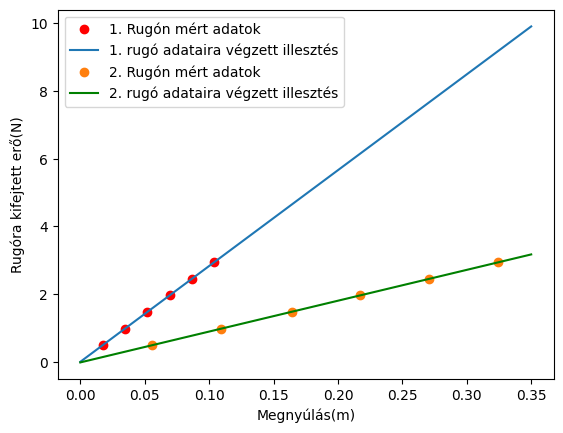

In [51]:
a = np.linspace(0, 0.35, 100)
plt.plot(megnyulasok_1, F, "ro", label="1. Rugón mért adatok")
plt.plot(a, linearis(a, megnyulas_illesztes_1[0][0], megnyulas_illesztes_1[0][1]), label="1. rugó adataira végzett illesztés")
plt.plot(megnyulasok_2, F, "o", label="2. Rugón mért adatok")
plt.plot(a, linearis(a, megnyulas_illesztes_2[0][0], megnyulas_illesztes_2[0][1]), "g", label="2. rugó adataira végzett illesztés")
plt.xlabel("Megnyúlás(m)")
plt.ylabel("Rugóra kifejtett erő(N)")
plt.legend()
plt.show()

In [52]:
rezges_illesztes_1_teljes = curve_fit(linearis, periodusidok_1 ** 2 / (4 * np.pi ** 2), tomegek)
rezges_illesztes_1_pontos = curve_fit(linearis, periodusidok_1[2:] ** 2 / (4 * np.pi ** 2), tomegek[2:])
rezges_illesztes_2 = curve_fit(linearis, periodusidok_2 ** 2 / (4 * np.pi ** 2), tomegek)

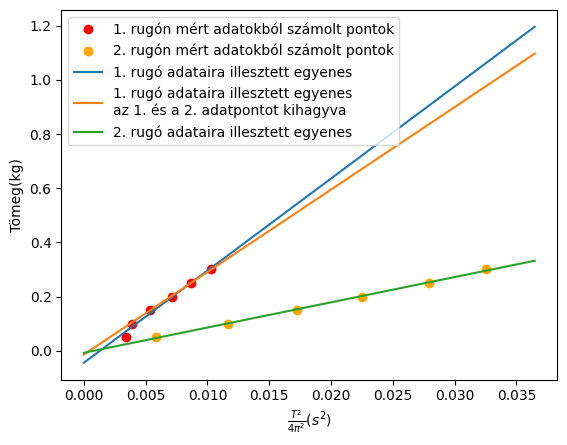

In [53]:
b = np.linspace(0, 1.2, 100) ** 2 / (4 * np.pi ** 2)
plt.plot(periodusidok_1 ** 2 / (4 * np.pi ** 2), tomegek, "ro", label="1. rugón mért adatokból számolt pontok")
plt.plot(periodusidok_2 ** 2 / (4 * np.pi ** 2), tomegek, "o", c="orange", label="2. rugón mért adatokból számolt pontok")
plt.plot(b, linearis(b, rezges_illesztes_1_teljes[0][0], rezges_illesztes_1_teljes[0][1]), label="1. rugó adataira illesztett egyenes")
plt.plot(b, linearis(b, rezges_illesztes_1_pontos[0][0], rezges_illesztes_1_pontos[0][1]), label="1. rugó adataira illesztett egyenes\naz 1. és a 2. adatpontot kihagyva")
plt.plot(b, linearis(b, rezges_illesztes_2[0][0], rezges_illesztes_2[0][1]), label="2. rugó adataira illesztett egyenes")
plt.legend()
plt.xlabel("$\\frac{T^2}{4\\pi^2}(s^2)$")
plt.ylabel("Tömeg(kg)")
plt.show()

In [55]:
for i in range(len(tomegek)):
    print(tomegek[i], end=" & ")
    print(mert_idok_2[i][0], end=" & ")
    print(mert_idok_2[i][1], end=" & ")
    print(mert_idok_2[i][2], end=" & ")
    print(atlag_idok_2[i], end=" & ")
    print(periodusidok_2[i], end=" ")
    print("\\\\")

0.05 & 4.82 & 4.8 & 4.78 & 4.800000000000001 & 0.4800000000000001 \\
0.1 & 6.72 & 6.74 & 6.87 & 6.776666666666667 & 0.6776666666666668 \\
0.15 & 8.17 & 8.32 & 8.24 & 8.243333333333334 & 0.8243333333333334 \\
0.2 & 9.38 & 9.43 & 9.49 & 9.433333333333335 & 0.9433333333333336 \\
0.25 & 10.49 & 10.55 & 10.45 & 10.496666666666666 & 1.0496666666666665 \\
0.3 & 11.38 & 11.31 & 11.3 & 11.33 & 1.133 \\


In [57]:
for i in range(len(tomegek)):
    print(tomegek[i], end=" & ")
    print(tavolsagok_2[i], end=" & ")
    print(megnyulasok_2[i], end=" ")
    print("\\\\")

0.05 & 0.3985 & 0.05549999999999994 \\
0.1 & 0.34450000000000003 & 0.10949999999999993 \\
0.15 & 0.2895 & 0.16449999999999998 \\
0.2 & 0.237 & 0.21699999999999997 \\
0.25 & 0.183 & 0.27099999999999996 \\
0.3 & 0.1295 & 0.32449999999999996 \\


In [59]:
print(megnyulas_illesztes_2[0])

[ 9.12168891 -0.01941145]


In [64]:
for i in range(len(tomegek)):
    print(megnyulasok_2[i], end=" & ")
    print(F[i], end=" & ")
    print(linearis(megnyulasok_2[i], megnyulas_illesztes_2[0][0], megnyulas_illesztes_2[0][1]), end=" & ")
    print(F[i] - linearis(megnyulasok_2[i], megnyulas_illesztes_2[0][0], megnyulas_illesztes_2[0][1]), end=" ")
    print("\\\\")

0.05549999999999994 & 0.49050000000000005 & 0.48684227961338994 & 0.0036577203866101082 \\
0.10949999999999993 & 0.9810000000000001 & 0.9794134806166848 & 0.0015865193833153324 \\
0.16449999999999998 & 1.4715 & 1.4811063705274483 & -0.009606370527448282 \\
0.21699999999999997 & 1.9620000000000002 & 1.9599950381695403 & 0.0020049618304598393 \\
0.27099999999999996 & 2.4525 & 2.4525662391728353 & -6.623917283521408e-05 \\
0.32449999999999996 & 2.943 & 2.940576595722396 & 0.0024234042776041242 \\


In [66]:
for i in range(len(tomegek)):
    print(tomegek[i], end=" & ")
    print(periodusidok_2[i] ** 2 / (4 * np.pi ** 2), end=" ")
    print("\\\\")

0.05 & 0.005836100177798658 \\
0.1 & 0.011632485266086841 \\
0.15 & 0.01721258058654919 \\
0.2 & 0.022540867435364428 \\
0.25 & 0.027908922848759257 \\
0.3 & 0.03251622222716224 \\


In [70]:
print(rezges_illesztes_2[0])

[ 9.31936019e+00 -7.73273883e-03]


In [76]:
for i in range(len(tomegek)):
    print(periodusidok_2[i] ** 2 / (4 * np.pi ** 2), end=" & ")
    print(tomegek[i], end=" & ")
    print(linearis(periodusidok_2[i] ** 2 / (4 * np.pi ** 2), rezges_illesztes_2[0][0], rezges_illesztes_2[0][1]), end=" & ")
    print(tomegek[i] - linearis(periodusidok_2[i] ** 2 / (4 * np.pi ** 2), rezges_illesztes_2[0][0], rezges_illesztes_2[0][1]), end=" ")
    print("\\\\")

0.005836100177798658 & 0.05 & 0.04665598085587509 & 0.00334401914412491 \\
0.011632485266086841 & 0.1 & 0.10067458131789764 & -0.0006745813178976323 \\
0.01721258058654919 & 0.15 & 0.15267749952723228 & -0.0026774995272322855 \\
0.022540867435364428 & 0.2 & 0.20233372388933757 & -0.002333723889337558 \\
0.027908922848759257 & 0.25 & 0.2523605658291662 & -0.002360565829166217 \\
0.03251622222716224 & 0.3 & 0.2952976482589976 & 0.004702351741002364 \\
